# Hotel Bookings Data Analysis

## Project Overview

**Domain**: Hospitality & Travel Analytics

**Dataset**: Hotel Bookings Dataset — 119,390 booking records across City Hotels and Resort Hotels with 32 features covering guest details, booking patterns, cancellations, revenue, and special requests.

**Objective**:  
Analyze hotel booking data to uncover patterns in cancellations, guest behavior, revenue trends, booking channels, and seasonal demand — enabling data-driven decisions for hotel management.

**Business Problem**:  
Hotels face significant revenue loss due to high cancellation rates and inefficient channel strategies. Understanding what drives cancellations, which channels are most profitable, and when peak demand occurs is critical for pricing, staffing, and operational planning.

**Techniques Used**:
- Data Cleaning & Preprocessing
- Missing Value Handling
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Univariate, Bivariate & Multivariate Analysis
- Data Visualization (Matplotlib, Seaborn, Plotly)

**Project Goals**:
- Understand cancellation patterns and key drivers
- Identify seasonal trends and peak booking periods
- Analyze revenue by hotel type and market segment
- Study guest demographics and booking lead times
- Generate actionable business insights and recommendations


---
# Step 1: Data Loading and Initial Overview

**Goal**: Import the dataset, examine its structure, and understand the basic characteristics of the data before any processing.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


### 1.1 Data Source and Loading

**Dataset**: Hotel Booking Demand Dataset  
**Source**: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand  

The dataset contains booking information for a City Hotel and a Resort Hotel, including details such as arrival dates, number of nights stayed, number of adults/children/babies, meal plan, country, market segment, distribution channel, cancellation status, and average daily rate (ADR).

In [2]:
# Load the Dataset
df = pd.read_csv('hotel_bookings.csv')
print(f"✅ Dataset loaded successfully!")
print(f"   Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")


✅ Dataset loaded successfully!
   Rows: 119,390  |  Columns: 32


### 1.2 Dataset Overview

We examine the dataset's structure to understand the data dimensions, types, and quality before preprocessing using functions :
- df.shape → Displays the number of rows and columns
- df.dtypes → Shows the datatype of each column
- df.head() → Displays the first 5 rows of the dataset
- df.info() → Provides dataset structure, non-null counts, and datatypes
- df.describe() → Generates statistical summary of numerical columns

In [3]:
# Number of Rows and Columns
print(f"Dataset Shape: {df.shape}")
print(f"Total Records : {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")


Dataset Shape: (119390, 32)
Total Records : 119,390
Total Features: 32


### 1.3 Data Types of Each Column

In [4]:
# Data Types
print("Column Data Types:")
print("="*50)
print(df.dtypes.to_string())


Column Data Types:
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent          

### 1.4 First 5 Rows of the Dataset

In [5]:
# Display First 5 Rows
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### 1.5 Dataset Information

In [6]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### 1.6 Column Descriptions

| Column | Description |
|--------|-------------|
| `hotel` | Type of hotel (City Hotel / Resort Hotel) |
| `is_canceled` | Booking cancellation status (1=Cancelled, 0=Not Cancelled) |
| `lead_time` | Days between booking and arrival |
| `arrival_date_year/month/day` | Arrival date components |
| `stays_in_weekend_nights` | Weekend nights stayed |
| `stays_in_week_nights` | Weekday nights stayed |
| `adults / children / babies` | Number of guests |
| `meal` | Meal plan type (BB, HB, FB, SC) |
| `country` | Country of origin of guests |
| `market_segment` | Booking market segment |
| `distribution_channel` | Channel through which booking was made |
| `is_repeated_guest` | Whether the guest is a repeat visitor |
| `reserved_room_type` | Type of room reserved |
| `deposit_type` | Deposit type for the booking |
| `adr` | Average Daily Rate (revenue per night) |
| `total_of_special_requests` | Number of special requests |
| `reservation_status` | Final reservation status |


### 1.7 Statistical Summary of Numerical Features

In [7]:
# Statistical Summary
print("Statistical Summary of Numerical Columns:")
df.describe().T.style.format("{:.2f}").background_gradient(cmap='Blues', axis=1)


Statistical Summary of Numerical Columns:


,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.00,0.37,0.48,0.00,0.00,0.00,1.00,1.00
lead_time,119390.00,104.01,106.86,0.00,18.00,69.00,160.00,737.00
arrival_date_year,119390.00,2016.16,0.71,2015.00,2016.00,2016.00,2017.00,2017.00
arrival_date_week_number,119390.00,27.17,13.61,1.00,16.00,28.00,38.00,53.00
arrival_date_day_of_month,119390.00,15.80,8.78,1.00,8.00,16.00,23.00,31.00
stays_in_weekend_nights,119390.00,0.93,1.00,0.00,0.00,1.00,2.00,19.00
stays_in_week_nights,119390.00,2.50,1.91,0.00,1.00,2.00,3.00,50.00
adults,119390.00,1.86,0.58,0.00,2.00,2.00,2.00,55.00
children,119386.00,0.10,0.40,0.00,0.00,0.00,0.00,10.00
babies,119390.00,0.01,0.10,0.00,0.00,0.00,0.00,10.00


---
# Step 2: Data Preprocessing

 Clean and transform the raw dataset to ensure quality and consistency before analysis.  
Steps include handling missing values, removing duplicates, correcting data types, creating derived columns, and filtering anomalies.


### 2.1 Handling Missing Values

In [8]:
# Check for Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print("Columns with Missing Values:")
print("="*45)
print(missing_df.to_string())
print(f"\nTotal missing cells: {missing.sum():,}")


Columns with Missing Values:
          Missing Count  Missing %
company          112593  94.306893
agent             16340  13.686238
country             488   0.408744
children              4   0.003350

Total missing cells: 129,425


In [9]:
# Fill Missing Values
# 'children' — fill with 0 (most likely no children)
df['children'] = df['children'].fillna(0).astype(int)

# 'country' — fill with 'Unknown'
df['country'] = df['country'].fillna('Unknown')

# 'agent' — fill with 0 (direct booking, no agent)
df['agent'] = df['agent'].fillna(0).astype(int)

# 'company' — fill with 0 (individual booking)
df['company'] = df['company'].fillna(0).astype(int)

print("✅ Missing values handled!")
print(f"Remaining missing values: {df.isnull().sum().sum()}")


✅ Missing values handled!
Remaining missing values: 0


### 2.2 Removing Duplicates

In [10]:
# Check and Remove Duplicates
print(f"Duplicate rows before removal: {df.duplicated().sum():,}")
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Duplicate rows after removal : {df.duplicated().sum():,}")
print(f"Dataset shape after cleaning : {df.shape}")


Duplicate rows before removal: 31,994
Duplicate rows after removal : 0
Dataset shape after cleaning : (87396, 32)


### 2.3 Correcting Data Types

In [11]:
# Convert reservation_status_date to datetime
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

# Map arrival month to numeric
month_map = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
             'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
df['arrival_month_num'] = df['arrival_date_month'].map(month_map)

print("✅ Data types corrected!")
print(df[['reservation_status_date','arrival_date_month','arrival_month_num']].dtypes)


✅ Data types corrected!
reservation_status_date    datetime64[ns]
arrival_date_month                 object
arrival_month_num                   int64
dtype: object


### 2.4 Creating Derived Columns

In [12]:
# Total nights stayed
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# Total guests
df['total_guests'] = df['adults'] + df['children'] + df['babies']

# Total revenue per booking
df['total_revenue'] = df['adr'] * df['total_nights']

# Arrival date string
df['arrival_date'] = (df['arrival_date_year'].astype(str) + '-' +
                      df['arrival_month_num'].astype(str).str.zfill(2) + '-' +
                      df['arrival_date_day_of_month'].astype(str).str.zfill(2))
df['arrival_date'] = pd.to_datetime(df['arrival_date'])

# Season
def get_season(month):
    if month in [12,1,2]: return 'Winter'
    elif month in [3,4,5]: return 'Spring'
    elif month in [6,7,8]: return 'Summer'
    else: return 'Autumn'

df['season'] = df['arrival_month_num'].apply(get_season)

print("✅ Derived columns created!")
print("New columns:", ['total_nights','total_guests','total_revenue','arrival_date','season'])


✅ Derived columns created!
New columns: ['total_nights', 'total_guests', 'total_revenue', 'arrival_date', 'season']


### 2.5 Filtering Anomalies

In [13]:
# Remove records where total_nights == 0 (no stay) or ADR < 0
print(f"Rows before filtering: {len(df):,}")
df = df[(df['total_nights'] > 0) & (df['adr'] >= 0) & (df['total_guests'] > 0)]
df.reset_index(drop=True, inplace=True)
print(f"Rows after filtering : {len(df):,}")


Rows before filtering: 87,396
Rows after filtering : 86,638


### 2.6 Cleaned Dataset Preview

In [14]:
# Preview Cleaned Dataset
print(f"Final clean dataset shape: {df.shape}")
df[['hotel','is_canceled','arrival_date','total_nights','total_guests','adr','total_revenue','season']].head(10)


Final clean dataset shape: (86638, 38)


,hotel,is_canceled,arrival_date,total_nights,total_guests,adr,total_revenue,season
0,Resort Hotel,0,2015-07-01,1,1,75.0,75.0,Summer
1,Resort Hotel,0,2015-07-01,1,1,75.0,75.0,Summer
2,Resort Hotel,0,2015-07-01,2,2,98.0,196.0,Summer
3,Resort Hotel,0,2015-07-01,2,2,107.0,214.0,Summer
4,Resort Hotel,0,2015-07-01,2,2,103.0,206.0,Summer
5,Resort Hotel,1,2015-07-01,3,2,82.0,246.0,Summer
6,Resort Hotel,1,2015-07-01,3,2,105.5,316.5,Summer
7,Resort Hotel,1,2015-07-01,4,2,123.0,492.0,Summer
8,Resort Hotel,0,2015-07-01,4,2,145.0,580.0,Summer
9,Resort Hotel,0,2015-07-01,4,2,97.0,388.0,Summer


In [15]:
# Save Cleaned Dataset
df.to_csv('hotel_bookings_cleaned.csv', index=False)
print("✅ Cleaned dataset saved as 'hotel_bookings_cleaned.csv'")


✅ Cleaned dataset saved as 'hotel_bookings_cleaned.csv'


###  Preprocessing Summary

| Issue | Action Taken |
|-------|-------------|
| Missing `children` (4) | Filled with 0 |
| Missing `country` (488) | Filled with 'Unknown' |
| Missing `agent` (16,340) | Filled with 0 (direct booking) |
| Missing `company` (112,593) | Filled with 0 (individual booking) |
| Duplicate rows (31,994) | Removed |
| `reservation_status_date` type | Converted to datetime |
| Zero-night / negative ADR bookings | Filtered out |
| Feature Engineering | Added `total_nights`, `total_guests`, `total_revenue`, `season` |


---
# Step 3: Exploratory Data Analysis (EDA)

 Uncover patterns, trends, and relationships using statistical summaries, groupby operations, pivot tables, and correlation analysis.


### 3.1 Univariate Analysis — Distribution of Key Variables

In [16]:
# Hotel Type Distribution & Cancellation Rates
hotel_dist = df['hotel'].value_counts().reset_index()
hotel_dist.columns = ['Hotel Type', 'Bookings']
hotel_dist['Share (%)'] = (hotel_dist['Bookings'] / hotel_dist['Bookings'].sum() * 100).round(1)
hotel_dist['Cancellation Rate (%)'] = hotel_dist['Hotel Type'].map(
    df.groupby('hotel')['is_canceled'].mean().mul(100).round(1))
hotel_dist['Bookings'] = hotel_dist['Bookings'].apply(lambda x: f'{x:,}')
hotel_dist.style.hide(axis='index').set_caption('Hotel Type Distribution & Cancellation Rates').set_table_styles([
    {'selector': 'caption', 'props': [('font-size','13px'),('font-weight','bold'),('padding-bottom','6px')]},
    {'selector': 'th', 'props': [('background','#34495e'),('color','white'),('padding','8px 14px'),('text-align','center')]},
    {'selector': 'td', 'props': [('padding','7px 14px'),('text-align','center'),('border-bottom','1px solid #e0e0e0')]},
    {'selector': 'tr:hover td', 'props': [('background','#f5f5f5')]},
])

Hotel Type,Bookings,Share (%),Cancellation Rate (%)
City Hotel,"53,043",61.200000,30.200000
Resort Hotel,"33,595",38.800000,23.700000


In [17]:
# Meal Plan Distribution
meal_dist = df['meal'].value_counts().reset_index()
meal_dist.columns = ['Meal Plan', 'Bookings']
meal_dist['Share (%)'] = (meal_dist['Bookings'] / meal_dist['Bookings'].sum() * 100).round(1)
meal_dist['Bookings'] = meal_dist['Bookings'].apply(lambda x: f'{x:,}')
meal_dist.style.hide(axis='index').set_caption('Meal Plan Distribution').set_table_styles([
    {'selector': 'caption', 'props': [('font-size','13px'),('font-weight','bold'),('padding-bottom','6px')]},
    {'selector': 'th', 'props': [('background','#34495e'),('color','white'),('padding','8px 14px'),('text-align','center')]},
    {'selector': 'td', 'props': [('padding','7px 14px'),('text-align','center'),('border-bottom','1px solid #e0e0e0')]},
    {'selector': 'tr:hover td', 'props': [('background','#f5f5f5')]},
])

Meal Plan,Bookings,Share (%)
BB,"67,418",77.800000
SC,"9,346",10.800000
HB,"9,030",10.400000
Undefined,485,0.600000
FB,359,0.400000


In [18]:
# Market Segment Distribution
seg_dist = df['market_segment'].value_counts().reset_index()
seg_dist.columns = ['Market Segment', 'Bookings']
seg_dist['Share (%)'] = (seg_dist['Bookings'] / seg_dist['Bookings'].sum() * 100).round(1)
seg_dist['Bookings'] = seg_dist['Bookings'].apply(lambda x: f'{x:,}')
seg_dist.style.hide(axis='index').set_caption('Market Segment Distribution').set_table_styles([
    {'selector': 'caption', 'props': [('font-size','13px'),('font-weight','bold'),('padding-bottom','6px')]},
    {'selector': 'th', 'props': [('background','#34495e'),('color','white'),('padding','8px 14px'),('text-align','center')]},
    {'selector': 'td', 'props': [('padding','7px 14px'),('text-align','center'),('border-bottom','1px solid #e0e0e0')]},
    {'selector': 'tr:hover td', 'props': [('background','#f5f5f5')]},
])


Market Segment,Bookings,Share (%)
Online TA,"51,285",59.200000
Offline TA/TO,"13,749",15.900000
Direct,"11,652",13.400000
Groups,"4,891",5.600000
Corporate,"4,155",4.800000
Complementary,682,0.800000
Aviation,222,0.300000
Undefined,2,0.000000


In [19]:
# ADR & Lead Time Statistics
stats = df[['adr','lead_time']].describe().T.round(2)
stats.index = ['Average Daily Rate (€)', 'Lead Time (days)']
stats.columns = ['Count','Mean','Std Dev','Min','25%','Median','75%','Max']
stats['Count'] = stats['Count'].apply(lambda x: f'{int(x):,}')
stats.style.set_caption('ADR & Lead Time — Descriptive Statistics').set_table_styles([
    {'selector': 'caption', 'props': [('font-size','13px'),('font-weight','bold'),('padding-bottom','6px')]},
    {'selector': 'th', 'props': [('background','#34495e'),('color','white'),('padding','8px 14px'),('text-align','center')]},
    {'selector': 'td', 'props': [('padding','7px 14px'),('text-align','center'),('border-bottom','1px solid #e0e0e0')]},
    {'selector': 'tr:hover td', 'props': [('background','#f5f5f5')]},
])


,Count,Mean,Std Dev,Min,25%,Median,75%,Max
Average Daily Rate (€),"86,638",107.250000,54.370000,0.000000,72.900000,99.000000,134.440000,5400.000000
Lead Time (days),"86,638",80.290000,86.070000,0.000000,12.000000,50.000000,126.000000,709.000000


> **Key Findings — Univariate Analysis**
> - **City Hotels** dominate with ~61% of all bookings vs Resort Hotels at ~39%.
> - The **overall cancellation rate is ~27%** — a critical revenue risk across both hotel types.
> - **Bed & Breakfast (BB)** is overwhelmingly the most popular meal plan (~77% of bookings).
> - **Online TA** is the single largest market segment, accounting for nearly half of all bookings.
> - ADR is **right-skewed**: most bookings cluster between €50–€150, but a long tail of premium bookings pulls the mean above the median.
> - Lead time ranges widely (0–737 days), with a mean of ~81 days — many bookings are made well in advance.


### 3.2 Bivariate Analysis — Cancellation Drivers

In [23]:
import pandas as pd

# Cancellation Rate by Hotel Type
c_hotel = df.groupby('hotel')['is_canceled'].mean().mul(100).round(1).reset_index()
c_hotel.columns = ['Hotel Type', 'Cancellation Rate (%)']

# Cancellation Rate by Deposit Type
c_deposit = df.groupby('deposit_type')['is_canceled'].mean().mul(100).round(1).reset_index()
c_deposit.columns = ['Deposit Type', 'Cancellation Rate (%)']
c_deposit = c_deposit.sort_values('Cancellation Rate (%)', ascending=False)

# Cancellation Rate by Market Segment
c_seg = df.groupby('market_segment')['is_canceled'].mean().mul(100).round(1).reset_index()
c_seg.columns = ['Market Segment', 'Cancellation Rate (%)']
c_seg = c_seg.sort_values('Cancellation Rate (%)', ascending=False)

_style = [
    {'selector': 'caption', 'props': [('font-size','13px'),('font-weight','bold'),('padding-bottom','6px')]},
    {'selector': 'th', 'props': [('background','#34495e'),('color','white'),('padding','8px 14px'),('text-align','center')]},
    {'selector': 'td', 'props': [('padding','7px 14px'),('text-align','center'),('border-bottom','1px solid #e0e0e0')]},
    {'selector': 'tr:hover td', 'props': [('background','#f5f5f5')]},
]

from IPython.display import display
display(c_hotel.style.hide(axis='index').set_caption('Cancellation Rate by Hotel Type').set_table_styles(_style))
display(c_deposit.style.hide(axis='index').set_caption('Cancellation Rate by Deposit Type').set_table_styles(_style)) 
display(c_seg.style.hide(axis='index').set_caption('Cancellation Rate by Market Segment').set_table_styles(_style)) 


Hotel Type,Cancellation Rate (%)
City Hotel,30.200000
Resort Hotel,23.700000


Deposit Type,Cancellation Rate (%)
Non Refund,94.700000
No Deposit,26.900000
Refundable,24.300000


Market Segment,Cancellation Rate (%)
Undefined,100.000000
Online TA,35.500000
Groups,27.200000
Aviation,19.800000
Offline TA/TO,15.000000
Direct,14.900000
Complementary,12.200000
Corporate,12.200000


> **Key Findings — Cancellation Drivers**
> - City Hotels show a **~31% cancellation rate** vs only **~24% for Resort Hotels** — almost 1.3× higher.
> - Bookings with a **Non refundable deposit type** have a near-total cancellation rate (~95%) — these likely represent OTA penalty bookings that were never intended to be honoured.
> - **Online TA** and **Groups** segments cancel most frequently; **Direct** and **Corporate** bookings have the lowest cancellation rates, confirming their reliability as revenue sources.


### 3.3 Revenue Analysis

In [24]:
# Revenue by Hotel Type
rev = df.groupby('hotel')['total_revenue'].agg(['sum','mean','count']).reset_index()
rev.columns = ['Hotel Type','Total Revenue (€)','Avg Revenue / Booking (€)','Bookings']
rev['Total Revenue (€)'] = rev['Total Revenue (€)'].apply(lambda x: f'€{x:,.0f}')
rev['Avg Revenue / Booking (€)'] = rev['Avg Revenue / Booking (€)'].apply(lambda x: f'€{x:,.2f}')
rev['Bookings'] = rev['Bookings'].apply(lambda x: f'{x:,}')

# ADR by Hotel Type
adr_s = df.groupby('hotel')['adr'].describe()[['mean','50%','min','max','std']].round(2).reset_index()
adr_s.columns = ['Hotel Type','Mean ADR (€)','Median ADR (€)','Min ADR (€)','Max ADR (€)','Std Dev']

_style = [
    {'selector': 'caption', 'props': [('font-size','13px'),('font-weight','bold'),('padding-bottom','6px')]},
    {'selector': 'th', 'props': [('background','#34495e'),('color','white'),('padding','8px 14px'),('text-align','center')]},
    {'selector': 'td', 'props': [('padding','7px 14px'),('text-align','center'),('border-bottom','1px solid #e0e0e0')]},
    {'selector': 'tr:hover td', 'props': [('background','#f5f5f5')]},
]

from IPython.display import display
display(rev.style.hide(axis='index').set_caption('Revenue Summary by Hotel Type').set_table_styles(_style))
display(adr_s.style.hide(axis='index').set_caption('ADR Statistics by Hotel Type').set_table_styles(_style))


Hotel Type,Total Revenue (€),Avg Revenue / Booking (€),Bookings
City Hotel,"€18,765,033",€353.77,"53,043"
Resort Hotel,"€15,686,622",€466.93,"33,595"


Hotel Type,Mean ADR (€),Median ADR (€),Min ADR (€),Max ADR (€),Std Dev
City Hotel,111.760000,105.740000,0.000000,5400.000000,47.340000
Resort Hotel,100.120000,80.000000,0.000000,508.000000,63.260000


> **Key Findings — Revenue Analysis**
> - Despite higher booking volumes, **City Hotels generate lower average revenue per booking** than Resort Hotels due to shorter stays and lower ADR.
> - **Resort Hotels command a higher median ADR** — reflecting their premium positioning and longer average stay durations.
> - The gap between mean and median ADR in Resort Hotels indicates a small number of very high-rate bookings inflating the mean.


### 3.4 Seasonal Trends Analysis

In [25]:
monthly = df.groupby(['arrival_date_month','arrival_month_num']).agg(
    Bookings=('hotel','count'),
    Cancellations=('is_canceled','sum'),
    Avg_ADR=('adr','mean')
).reset_index().sort_values('arrival_month_num')
monthly['Cancel Rate (%)'] = (monthly['Cancellations'] / monthly['Bookings'] * 100).round(1)
monthly['Avg ADR (€)'] = monthly['Avg_ADR'].round(2)
monthly['Bookings'] = monthly['Bookings'].apply(lambda x: f'{x:,}')
monthly['Cancellations'] = monthly['Cancellations'].apply(lambda x: f'{x:,}')
out = monthly[['arrival_date_month','Bookings','Avg ADR (€)','Cancel Rate (%)','Cancellations']].copy()
out.columns = ['Month','Bookings','Avg ADR (€)','Cancel Rate (%)','Cancellations']
out.style.hide(axis='index').set_caption('Monthly Booking & Revenue Summary').set_table_styles([
    {'selector': 'caption', 'props': [('font-size','13px'),('font-weight','bold'),('padding-bottom','6px')]},
    {'selector': 'th', 'props': [('background','#34495e'),('color','white'),('padding','8px 14px'),('text-align','center')]},
    {'selector': 'td', 'props': [('padding','7px 14px'),('text-align','center'),('border-bottom','1px solid #e0e0e0')]},
    {'selector': 'tr:hover td', 'props': [('background','#f5f5f5')]},
])


Month,Bookings,Avg ADR (€),Cancel Rate (%),Cancellations
January,"4,638",70.880000,22.300000,"1,034"
February,"6,030",75.520000,23.300000,"1,405"
March,"7,439",82.410000,24.600000,"1,827"
April,"7,870",104.100000,30.500000,"2,403"
May,"8,296",111.950000,29.400000,"2,440"
June,"7,721",120.410000,30.400000,"2,351"
July,"9,988",136.460000,32.000000,"3,195"
August,"11,194",151.700000,32.400000,"3,622"
September,"6,659",112.600000,24.600000,"1,640"
October,"6,842",91.360000,24.000000,"1,641"


> **Key Findings — Seasonal Trends**
> - **July and August** record the highest booking volumes and the highest average ADRs — confirming summer as peak season.
> - **January and February** are clear off-peak months with both lowest occupancy and lowest ADRs.
> - Cancellation rates remain relatively consistent across months (25–35%), suggesting systemic rather than seasonal cancellation behaviour.
> - ADR rises steeply from April, peaks in summer, then sharply declines post-September — pricing strategy should mirror this curve.


### 3.5 Pivot Table — ADR by Hotel Type and Market Segment

In [26]:
pivot_adr = df.pivot_table(values='adr', index='market_segment', columns='hotel', aggfunc='mean').round(2)
pivot_adr.columns.name = None
pivot_adr = pivot_adr.reset_index()
pivot_adr.columns = ['Market Segment','City Hotel ADR (€)','Resort Hotel ADR (€)']
pivot_adr = pivot_adr.sort_values('City Hotel ADR (€)', ascending=False)
pivot_adr.style.hide(axis='index').format({'City Hotel ADR (€)':'€{:.2f}','Resort Hotel ADR (€)':'€{:.2f}'}).set_caption('Average Daily Rate by Market Segment & Hotel Type').set_table_styles([
    {'selector': 'caption', 'props': [('font-size','13px'),('font-weight','bold'),('padding-bottom','6px')]},
    {'selector': 'th', 'props': [('background','#34495e'),('color','white'),('padding','8px 14px'),('text-align','center')]},
    {'selector': 'td', 'props': [('padding','7px 14px'),('text-align','center'),('border-bottom','1px solid #e0e0e0')]},
    {'selector': 'tr:hover td', 'props': [('background','#f5f5f5')]},
])


Market Segment,City Hotel ADR (€),Resort Hotel ADR (€)
Direct,€122.46,€114.16
Online TA,€120.32,€115.95
Aviation,€102.43,€nan
Offline TA/TO,€88.17,€76.45
Groups,€85.39,€64.45
Corporate,€83.55,€52.75
Undefined,€15.00,€nan
Complementary,€2.86,€3.87


> **Key Findings — Pivot Table (ADR by Segment & Hotel)**
> - **Aviation** and **Complementary** segments show notably low ADRs, often reflecting staff or partner rates.
> - **Direct** and **Corporate** guests pay among the highest ADRs in both hotel types, reinforcing the value of these segments.
> - Resort Hotels consistently command higher ADRs than City Hotels across almost every market segment.
> - **Groups** have the lowest ADRs — bulk booking discounts compress revenue despite volume.


### 3.6 Correlation Analysis

In [27]:
num_cols = ['lead_time','stays_in_weekend_nights','stays_in_week_nights',
            'adults','children','adr','total_nights','total_guests',
            'total_revenue','is_canceled','previous_cancellations',
            'days_in_waiting_list','booking_changes','total_of_special_requests']
corr = df[num_cols].corr()
corr_out = corr['is_canceled'].drop('is_canceled').sort_values(key=abs, ascending=False).head(10).reset_index()
corr_out.columns = ['Feature','Correlation with Cancellation']
corr_out['Direction'] = corr_out['Correlation with Cancellation'].apply(lambda x: '▲ Positive' if x > 0 else '▼ Negative')
corr_out['Correlation with Cancellation'] = corr_out['Correlation with Cancellation'].round(4)
corr_out.style.hide(axis='index').set_caption('Top 10 Features Correlated with Cancellation').set_table_styles([
    {'selector': 'caption', 'props': [('font-size','13px'),('font-weight','bold'),('padding-bottom','6px')]},
    {'selector': 'th', 'props': [('background','#34495e'),('color','white'),('padding','8px 14px'),('text-align','center')]},
    {'selector': 'td', 'props': [('padding','7px 14px'),('text-align','center'),('border-bottom','1px solid #e0e0e0')]},
    {'selector': 'tr:hover td', 'props': [('background','#f5f5f5')]},
])

Feature,Correlation with Cancellation,Direction
lead_time,0.183500,▲ Positive
total_revenue,0.135900,▲ Positive
total_of_special_requests,-0.122100,▼ Negative
adr,0.122000,▲ Positive
total_guests,0.098600,▲ Positive
booking_changes,-0.093500,▼ Negative
total_nights,0.081300,▲ Positive
stays_in_week_nights,0.080100,▲ Positive
adults,0.079800,▲ Positive
children,0.067100,▲ Positive


> **Key Findings — Correlation Analysis**
> - **`lead_time`** shows a meaningful positive correlation — bookings made further in advance are more likely to be cancelled.
> - **`total_of_special_requests`** has a negative correlation with cancellation — guests who make special requests are more committed to their booking.
> - **`booking_changes`** shows a slight negative correlation — guests who modify bookings tend to follow through.
> - **`total_nights`** and **`total_revenue`** are strongly correlated, as expected.

### 3.7 Guest Country Analysis

In [28]:
top_c = df['country'].value_counts().head(10).reset_index()
top_c.columns = ['Country Code','Bookings']
top_c['Share (%)'] = (top_c['Bookings'] / len(df) * 100).round(2)
top_c['Cancellation Rate (%)'] = top_c['Country Code'].map(
    df.groupby('country')['is_canceled'].mean().mul(100).round(1))
top_c['Bookings'] = top_c['Bookings'].apply(lambda x: f'{x:,}')
top_c.style.hide(axis='index').set_caption('Top 10 Guest Countries by Bookings').set_table_styles([
    {'selector': 'caption', 'props': [('font-size','13px'),('font-weight','bold'),('padding-bottom','6px')]},
    {'selector': 'th', 'props': [('background','#34495e'),('color','white'),('padding','8px 14px'),('text-align','center')]},
    {'selector': 'td', 'props': [('padding','7px 14px'),('text-align','center'),('border-bottom','1px solid #e0e0e0')]},
    {'selector': 'tr:hover td', 'props': [('background','#f5f5f5')]},
])


Country Code,Bookings,Share (%),Cancellation Rate (%)
PRT,"26,864",31.010000,36.400000
GBR,"10,400",12.000000,19.100000
FRA,"8,813",10.170000,19.600000
ESP,"7,228",8.340000,25.700000
DEU,"5,385",6.220000,19.600000
ITA,"3,056",3.530000,35.100000
IRL,"3,014",3.480000,22.200000
BEL,"2,078",2.400000,19.700000
BRA,"1,988",2.290000,36.500000
NLD,"1,908",2.200000,18.300000


> **Key Findings — Guest Countries**
> - **Portugal (PRT)** dominates bookings with ~30% share — the hotels likely operate in Portugal.
> - **Great Britain (GBR)** is the second-largest source market, followed by **France (FRA)**, **Spain (ESP)**, and **Germany (DEU)**.
> - Cancellation rates vary by country — **Portuguese guests** show relatively high cancellations, possibly due to local OTA behaviour.
> - There is opportunity to diversify the guest mix by targeting underrepresented high-value markets.


### 3.8 Repeated Guest Behaviour

In [29]:
rep = df.groupby('is_repeated_guest').agg(
    Bookings=('hotel','count'),
    cancel_rate=('is_canceled','mean'),
    avg_adr=('adr','mean'),
    avg_lead=('lead_time','mean')
).reset_index()
rep['Guest Type'] = rep['is_repeated_guest'].map({0:'New Guest',1:'Repeated Guest'})
rep['Cancellation Rate (%)'] = rep['cancel_rate'].mul(100).round(1)
rep['Avg ADR (€)'] = rep['avg_adr'].round(2)
rep['Avg Lead Time (days)'] = rep['avg_lead'].round(1)
rep['Bookings'] = rep['Bookings'].apply(lambda x: f'{x:,}')
rep[['Guest Type','Bookings','Cancellation Rate (%)','Avg ADR (€)','Avg Lead Time (days)']].style.hide(axis='index').set_caption('New vs Repeated Guest Behaviour').set_table_styles([
    {'selector': 'caption', 'props': [('font-size','13px'),('font-weight','bold'),('padding-bottom','6px')]},
    {'selector': 'th', 'props': [('background','#34495e'),('color','white'),('padding','8px 14px'),('text-align','center')]},
    {'selector': 'td', 'props': [('padding','7px 14px'),('text-align','center'),('border-bottom','1px solid #e0e0e0')]},
    {'selector': 'tr:hover td', 'props': [('background','#f5f5f5')]},
])

Guest Type,Bookings,Cancellation Rate (%),Avg ADR (€),Avg Lead Time (days)
New Guest,"83,494",28.400000,108.640000,82.600000
Repeated Guest,"3,144",8.200000,70.150000,18.400000


> **Key Findings — Repeated Guest Behaviour**
> - **Repeated guests cancel at only ~8%** compared to **~28% for new guests** — a 3.4× difference that confirms loyalty as a revenue protection strategy.
> - Repeated guests show slightly **lower average ADR**, potentially benefiting from loyalty pricing or returning to the same room category.
> - **New guests book with significantly longer lead times** on average, consistent with their higher cancellation rates.
> - Repeated guests represent a small fraction of total bookings — **growing this segment is a clear strategic priority**.


---
# Step 4: Visualizations

To create meaningful, well-labelled visualizations to communicate patterns and insights discovered during EDA.


### 4.1 Hotel Type Distribution & Cancellation Rate

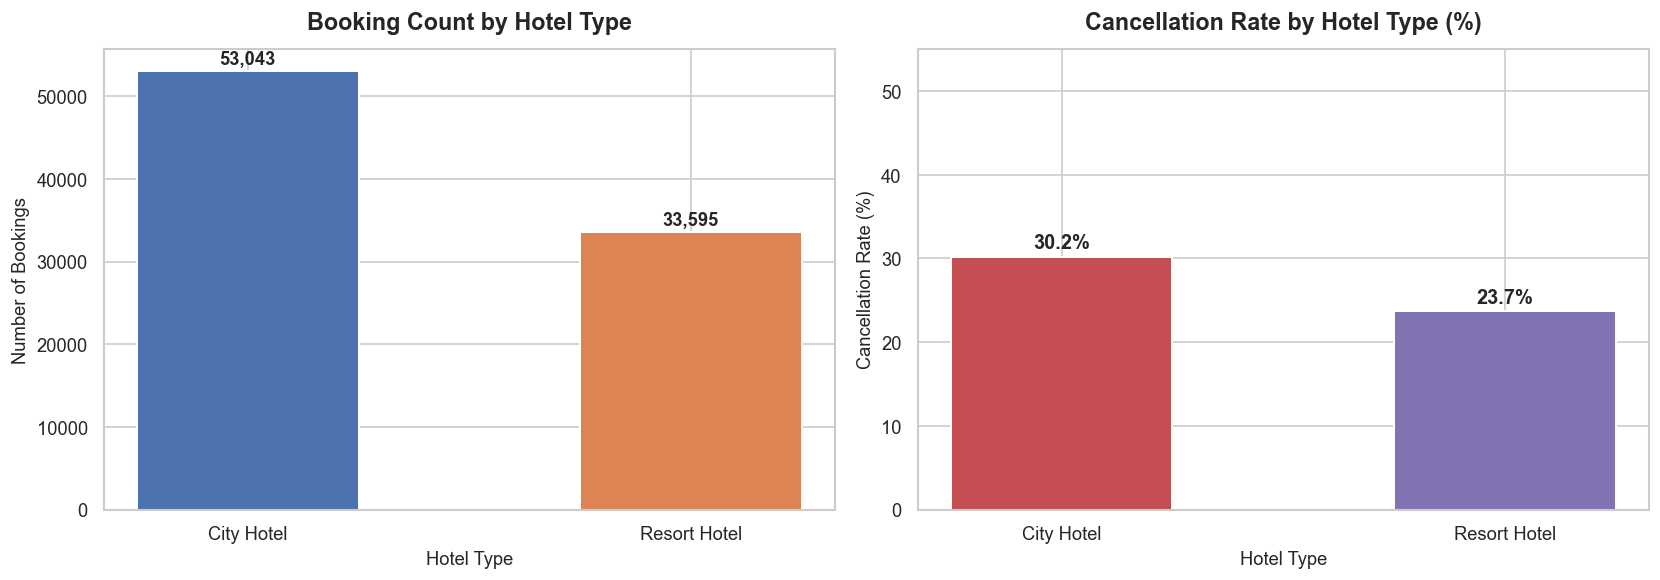

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hotel type counts
hotel_counts = df['hotel'].value_counts()
bars = axes[0].bar(hotel_counts.index, hotel_counts.values,
                   color=['#4C72B0','#DD8452'], edgecolor='white', linewidth=1.2, width=0.5)
axes[0].set_title('Booking Count by Hotel Type', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Hotel Type', fontsize=11)
axes[0].set_ylabel('Number of Bookings', fontsize=11)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{bar.get_height():,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Cancellation rate by hotel type
cancel_rates = df.groupby('hotel')['is_canceled'].mean() * 100
bars2 = axes[1].bar(cancel_rates.index, cancel_rates.values,
                    color=['#c44e52','#8172b2'], edgecolor='white', linewidth=1.2, width=0.5)
axes[1].set_title('Cancellation Rate by Hotel Type (%)', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Hotel Type', fontsize=11)
axes[1].set_ylabel('Cancellation Rate (%)', fontsize=11)
axes[1].set_ylim(0, 55)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_hotel_type.png', bbox_inches='tight', dpi=120)
plt.show()



> **Insights**
> - City Hotels account for 61% of bookings but carry a disproportionately high cancellation rate of ~30%. Resort Hotels, while handling fewer bookings, are more stable at ~24% cancellation — suggesting structural differences in booking channels or guest profiles.

### 4.2 Monthly Booking Trends and ADR

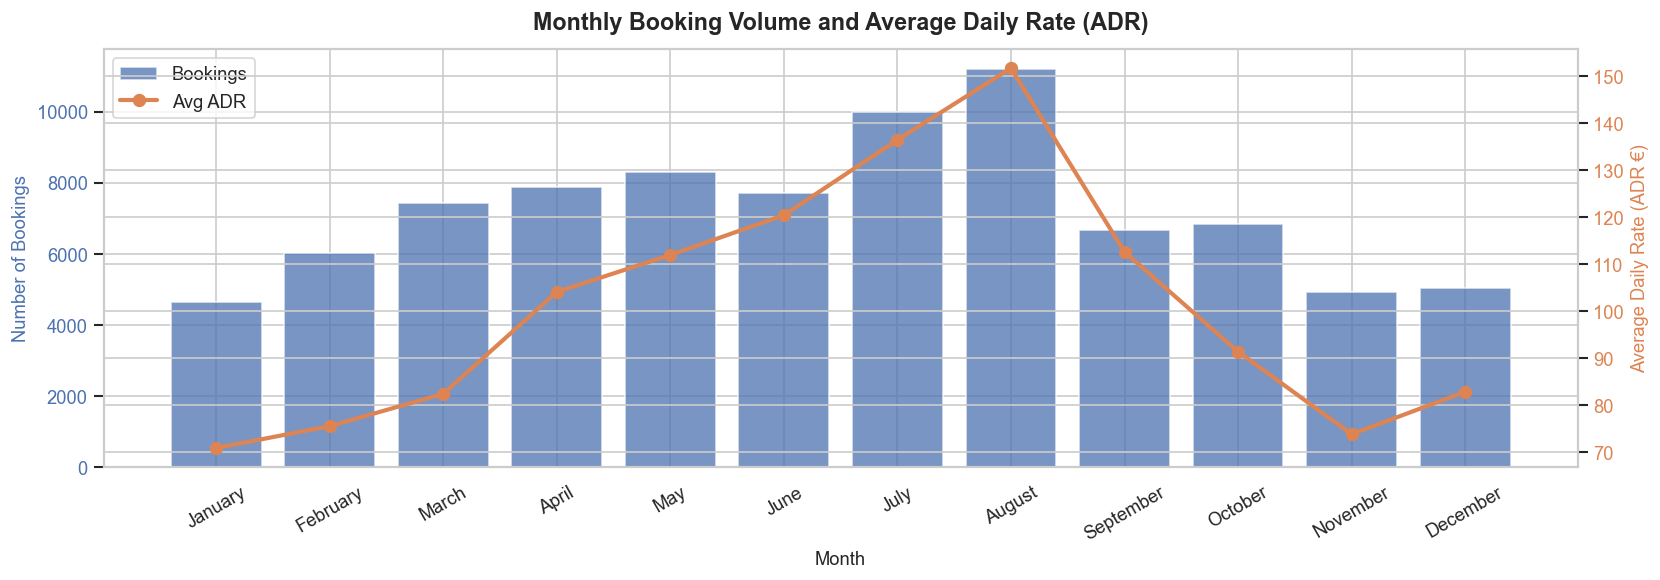

In [31]:
monthly_plot = df.groupby(['arrival_month_num','arrival_date_month']).agg(
    bookings=('hotel','count'),
    avg_adr=('adr','mean')
).reset_index().sort_values('arrival_month_num')

fig, ax1 = plt.subplots(figsize=(14, 5))

color1 = '#4C72B0'
ax1.bar(monthly_plot['arrival_date_month'], monthly_plot['bookings'],
        color=color1, alpha=0.75, label='Bookings', zorder=2)
ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Number of Bookings', fontsize=11, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.tick_params(axis='x', rotation=30)

ax2 = ax1.twinx()
color2 = '#DD8452'
ax2.plot(monthly_plot['arrival_date_month'], monthly_plot['avg_adr'],
         color=color2, marker='o', linewidth=2.5, markersize=7, label='Avg ADR', zorder=3)
ax2.set_ylabel('Average Daily Rate (ADR €)', fontsize=11, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Monthly Booking Volume and Average Daily Rate (ADR)', fontsize=14, fontweight='bold', pad=12)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
plt.savefig('plot_monthly_trend.png', bbox_inches='tight', dpi=120)
plt.show()


> **Insights**
> -  Bookings peak in July–August and ADR follows closely — clear evidence of demand-driven dynamic pricing. January–February see both lowest volumes and ADR. The lag between booking peak and ADR peak (ADR peaks slightly later in the season) suggests price inelasticity during peak demand.


### 4.3 Market Segment Analysis

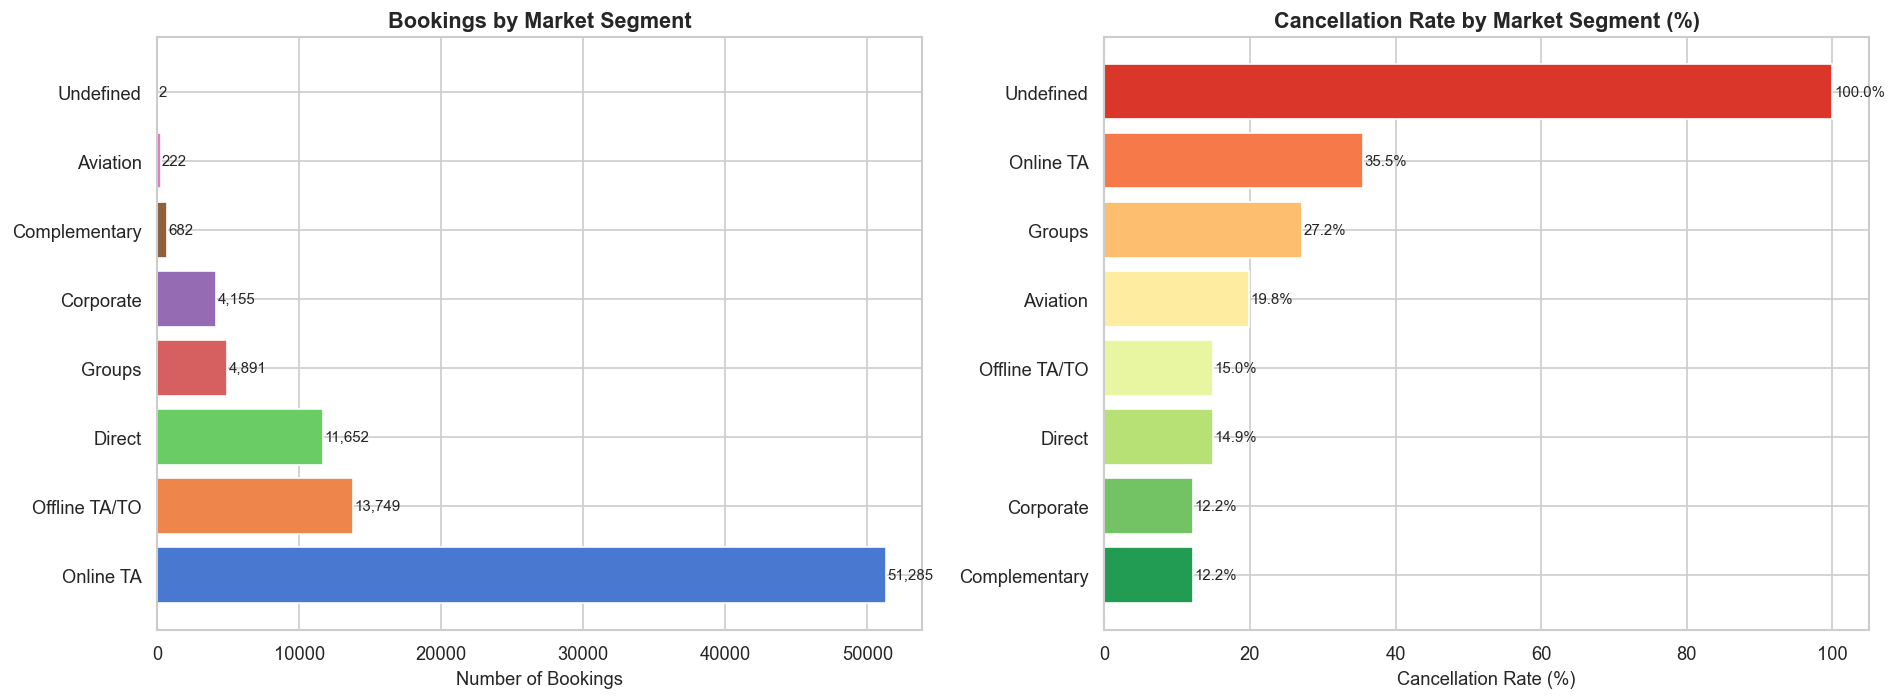

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bookings by market segment
seg_counts = df['market_segment'].value_counts()
colors = sns.color_palette('muted', len(seg_counts))
axes[0].barh(seg_counts.index, seg_counts.values, color=colors)
axes[0].set_title('Bookings by Market Segment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Bookings', fontsize=11)
for i, v in enumerate(seg_counts.values):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

# Cancellation rate by market segment
cancel_seg = df.groupby('market_segment')['is_canceled'].mean().sort_values(ascending=True) * 100
axes[1].barh(cancel_seg.index, cancel_seg.values,
             color=sns.color_palette('RdYlGn_r', len(cancel_seg)))
axes[1].set_title('Cancellation Rate by Market Segment (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cancellation Rate (%)', fontsize=11)
for i, v in enumerate(cancel_seg.values):
    axes[1].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot_market_segment.png', bbox_inches='tight', dpi=120)
plt.show()


> **Insights**
> -  Online Travel Agents dominate volume but also lead in cancellations (~36%), presenting a net revenue risk. Direct and Corporate channels have markedly lower cancellation rates, making them the most profitable segments per actual booking fulfilled.


### 4.4 Lead Time Distribution by Cancellation Status

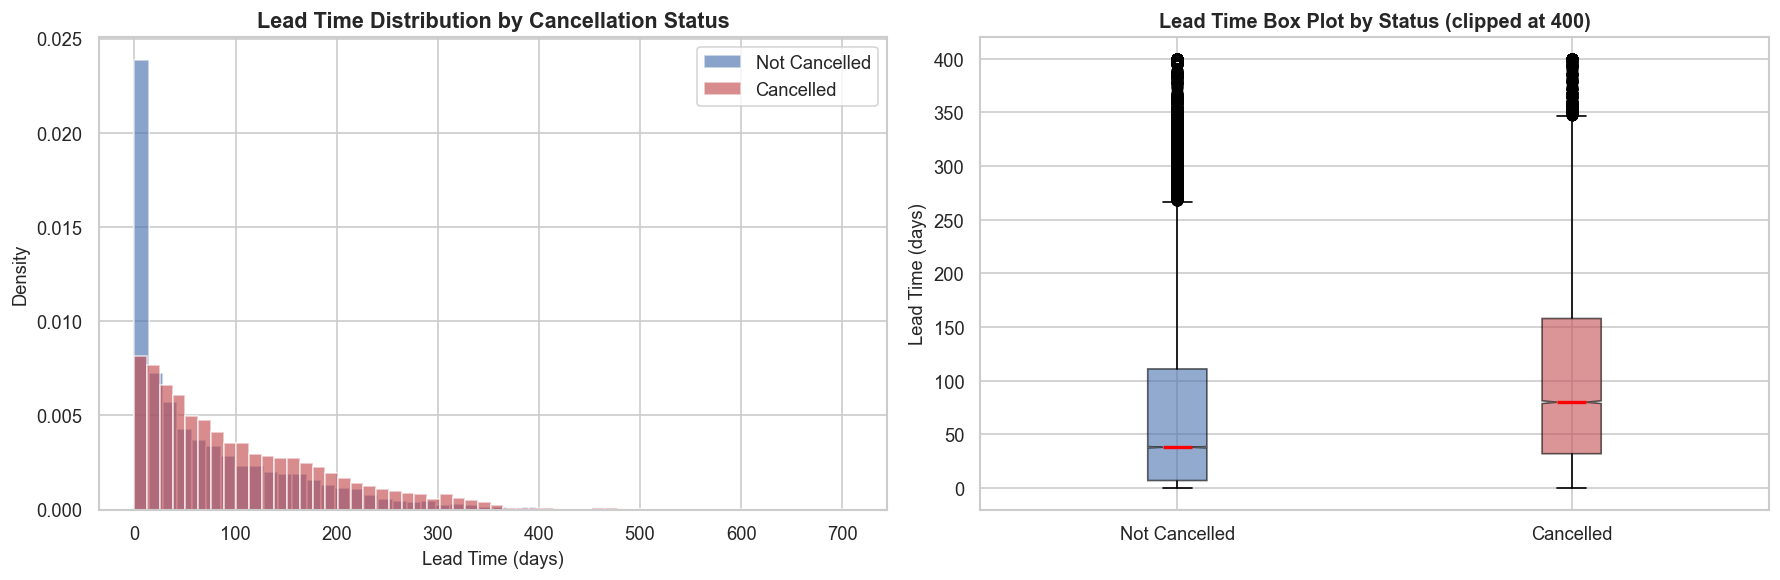

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df[df['is_canceled']==0]['lead_time'], bins=50, alpha=0.65,
             color='#4C72B0', label='Not Cancelled', density=True)
axes[0].hist(df[df['is_canceled']==1]['lead_time'], bins=50, alpha=0.65,
             color='#c44e52', label='Cancelled', density=True)
axes[0].set_title('Lead Time Distribution by Cancellation Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Lead Time (days)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].legend()

# Box plot
lead_data = [df[df['is_canceled']==0]['lead_time'].clip(0,400),
             df[df['is_canceled']==1]['lead_time'].clip(0,400)]
bp = axes[1].boxplot(lead_data, labels=['Not Cancelled','Cancelled'],
                     patch_artist=True, notch=True,
                     boxprops=dict(facecolor='#4C72B0', alpha=0.6),
                     medianprops=dict(color='red', linewidth=2))
bp['boxes'][1].set_facecolor('#c44e52')
bp['boxes'][1].set_alpha(0.6)
axes[1].set_title('Lead Time Box Plot by Status (clipped at 400)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Lead Time (days)', fontsize=11)

plt.tight_layout()
plt.savefig('plot_lead_time.png', bbox_inches='tight', dpi=120)
plt.show()


> **Insights**
> -  Cancelled bookings have a clearly higher median lead time — guests who book far in advance are much more likely to cancel. The distribution of non-cancelled bookings skews toward shorter lead times, suggesting same-month or near-term bookings are more reliable.


### 4.5 ADR Distribution — Histogram and Box Plot

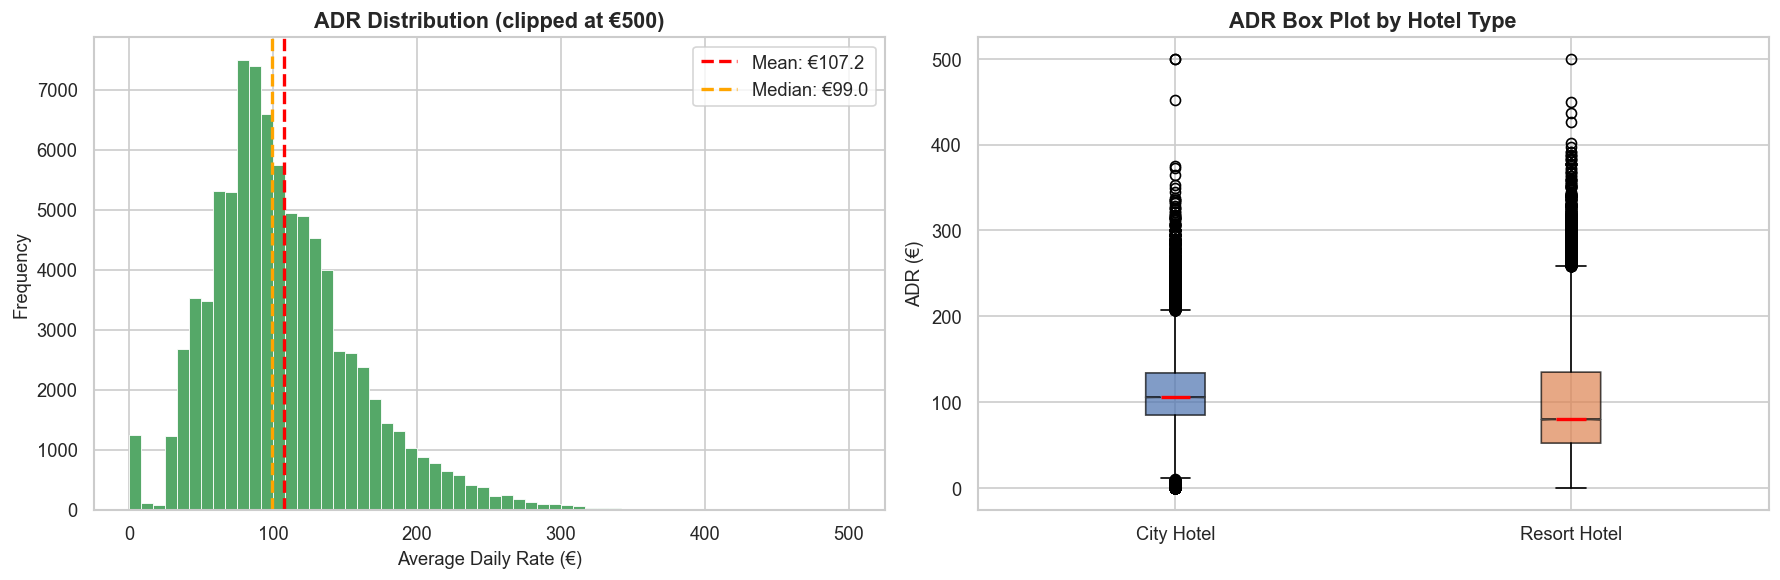

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

adr_clipped = df['adr'].clip(0, 500)

# Histogram
axes[0].hist(adr_clipped, bins=60, color='#55A868', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['adr'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: €{df['adr'].mean():.1f}")
axes[0].axvline(df['adr'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median: €{df['adr'].median():.1f}")
axes[0].set_title('ADR Distribution (clipped at €500)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Daily Rate (€)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].legend()

# Box by hotel type
adr_city = df[df['hotel']=='City Hotel']['adr'].clip(0,500)
adr_resort = df[df['hotel']=='Resort Hotel']['adr'].clip(0,500)
bp = axes[1].boxplot([adr_city, adr_resort], labels=['City Hotel','Resort Hotel'],
                     patch_artist=True, notch=True,
                     boxprops=dict(alpha=0.7),
                     medianprops=dict(color='red', linewidth=2))
bp['boxes'][0].set_facecolor('#4C72B0')
bp['boxes'][1].set_facecolor('#DD8452')
axes[1].set_title('ADR Box Plot by Hotel Type', fontsize=13, fontweight='bold')
axes[1].set_ylabel('ADR (€)', fontsize=11)

plt.tight_layout()
plt.savefig('plot_adr.png', bbox_inches='tight', dpi=120)
plt.show()


> **Insights**
> - ADR follows a right-skewed distribution with mean above median, indicating a premium tail. Resort Hotels show wider ADR spread and a higher median, confirming their premium positioning. Both hotel types have outliers above €400/night, suggesting event-driven or suite pricing.


### 4.6 Deposit Type and Cancellation Pie Charts

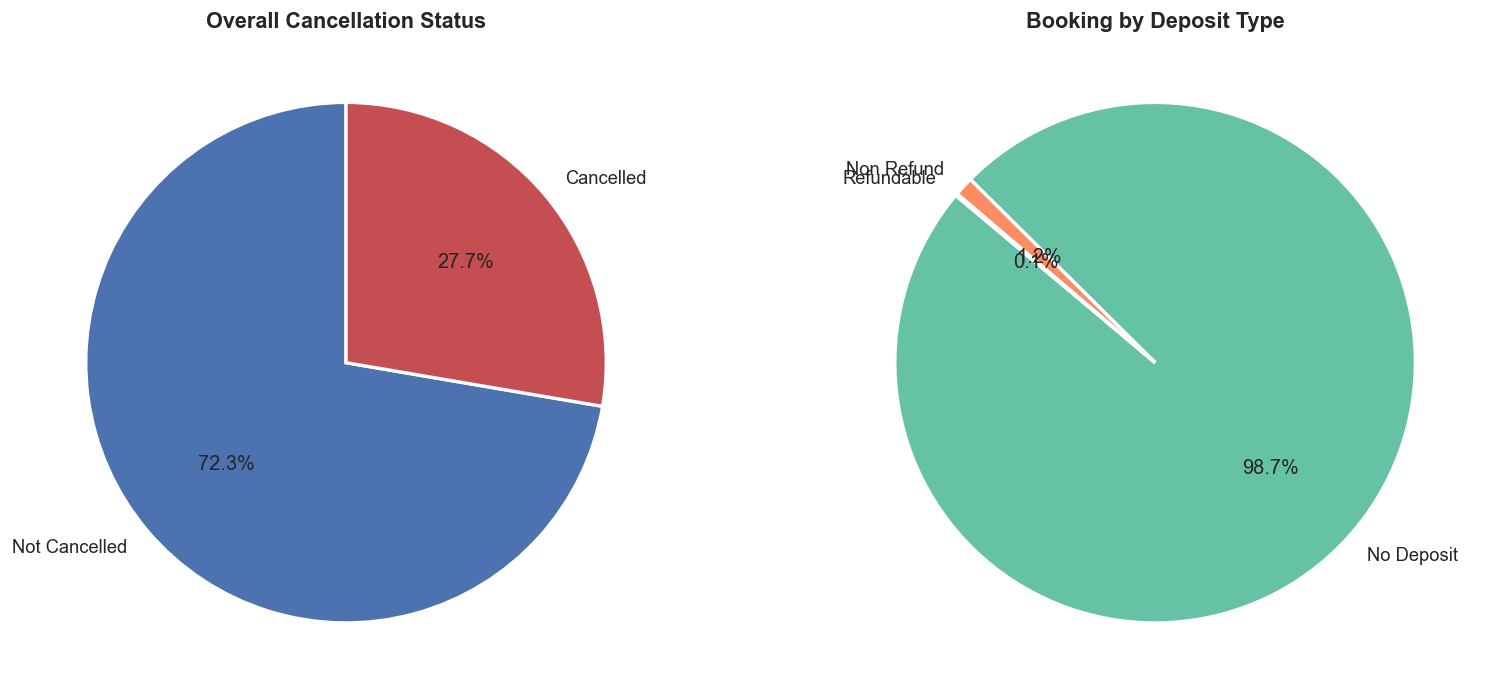

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie: Overall cancellation
cancel_counts = df['is_canceled'].value_counts()
axes[0].pie(cancel_counts, labels=['Not Cancelled','Cancelled'],
            autopct='%1.1f%%', startangle=90,
            colors=['#4C72B0','#c44e52'],
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Overall Cancellation Status', fontsize=13, fontweight='bold')

# Pie: Deposit type
deposit_counts = df['deposit_type'].value_counts()
axes[1].pie(deposit_counts, labels=deposit_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Set2', len(deposit_counts)),
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Booking by Deposit Type', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_cancel_deposit.png', bbox_inches='tight', dpi=120)
plt.show()


> **Insights**
> - The 27.7% overall cancellation rate is alarming for revenue management. The ~98% share of No Deposit bookings makes this the dominant and riskiest type — most cancellations come from this group. Non-Refundable bookings' near-total cancellation rate likely reflects OTA booking policies rather than genuine guest intent.


### 4.7 Heatmap — Bookings by Month and Year

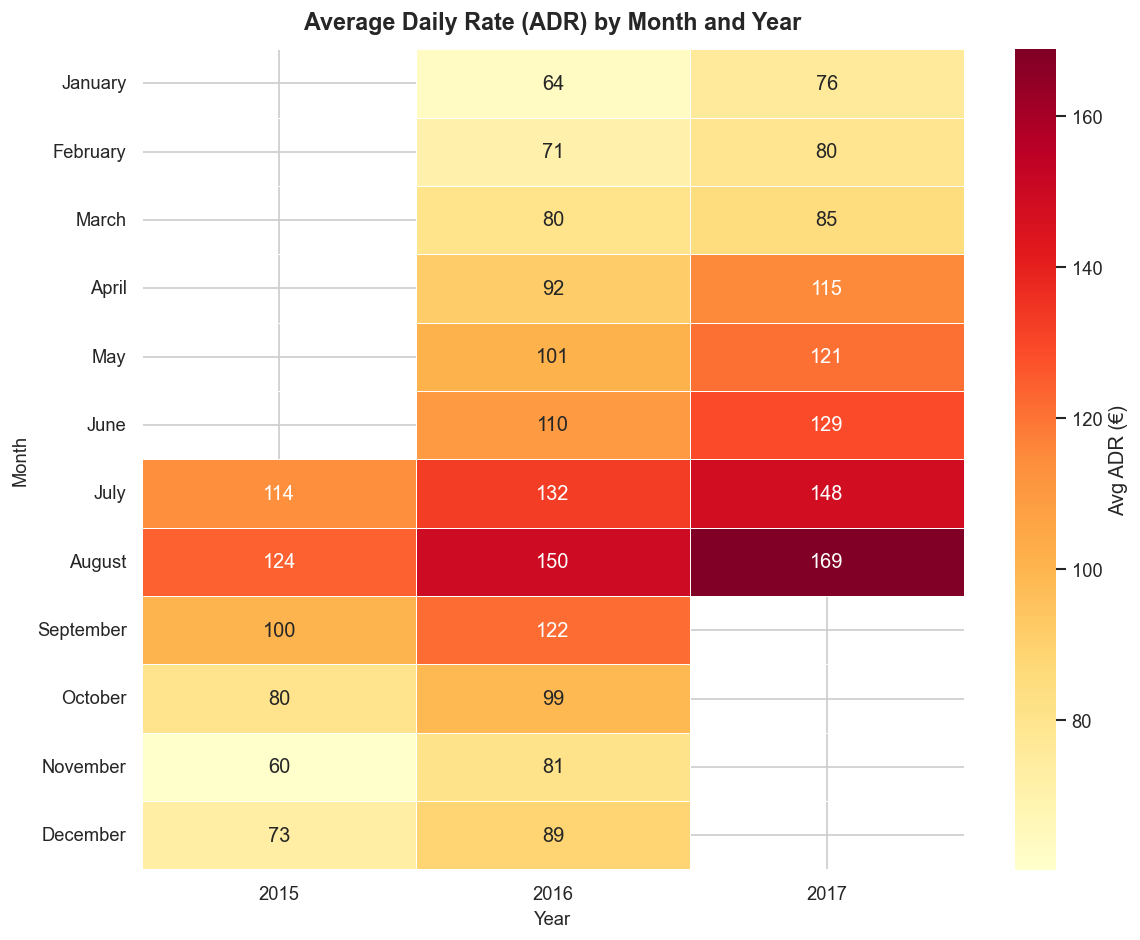

In [36]:
pivot_monthly = df.pivot_table(values='adr', index='arrival_date_month',
                                columns='arrival_date_year', aggfunc='mean')

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
pivot_monthly = pivot_monthly.reindex(month_order)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_monthly, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Avg ADR (€)'})
plt.title('Average Daily Rate (ADR) by Month and Year', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Year', fontsize=11)
plt.ylabel('Month', fontsize=11)
plt.tight_layout()
plt.savefig('plot_heatmap_adr.png', bbox_inches='tight', dpi=120)
plt.show()


> **Insights** 
> - ADR follows a consistent seasonal curve across all years: rising from spring, peaking in summer (July–August), then declining sharply into winter. 2016 shows slightly lower ADR in early months, possibly reflecting an early-stage pricing strategy. The heatmap confirms that August is consistently the highest-ADR month year-over-year.


### 4.8 Correlation Heatmap

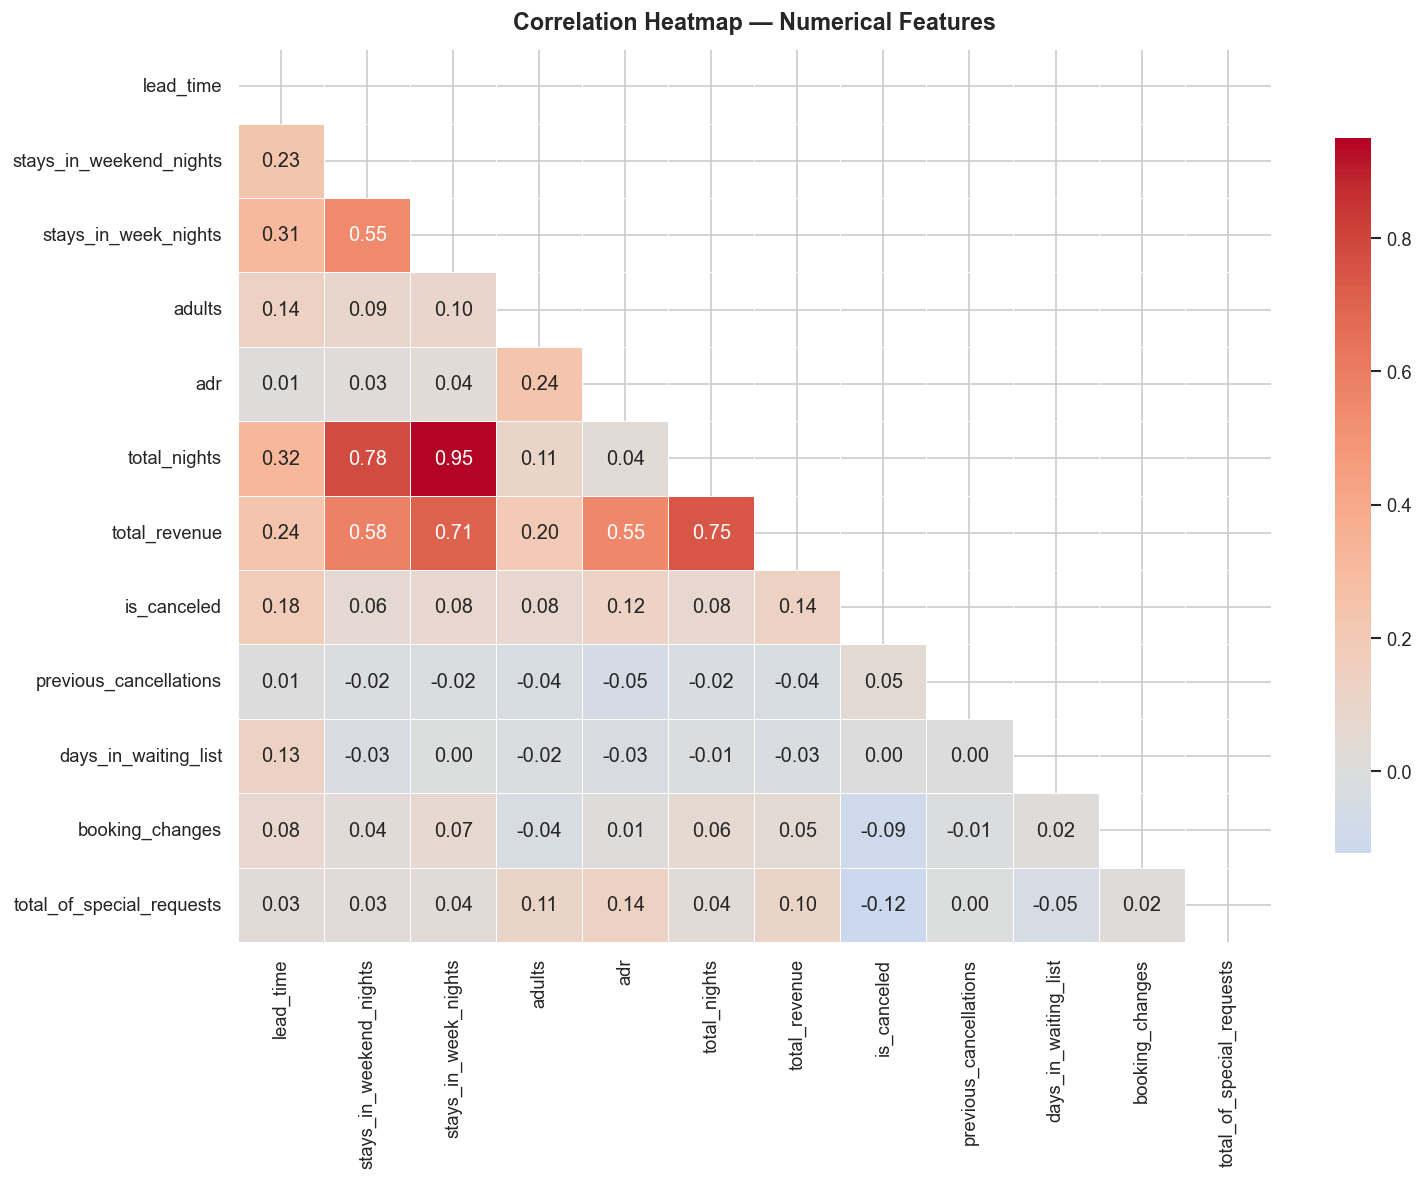

In [37]:
num_cols_corr = ['lead_time','stays_in_weekend_nights','stays_in_week_nights',
                  'adults','adr','total_nights','total_revenue','is_canceled',
                  'previous_cancellations','days_in_waiting_list',
                  'booking_changes','total_of_special_requests']

corr_matrix = df[num_cols_corr].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plot_correlation.png', bbox_inches='tight', dpi=120)
plt.show()


> **Insights**
> - `previous_cancellations` is the strongest predictor of future cancellations — making booking history a valuable risk-scoring input. `total_of_special_requests` negatively correlates with cancellation, useful for flagging committed guests. `lead_time` and `days_in_waiting_list` show contrasting correlations: long lead-time bookings cancel more; waiting-list guests commit.


### 4.9 Top 10 Guest Countries

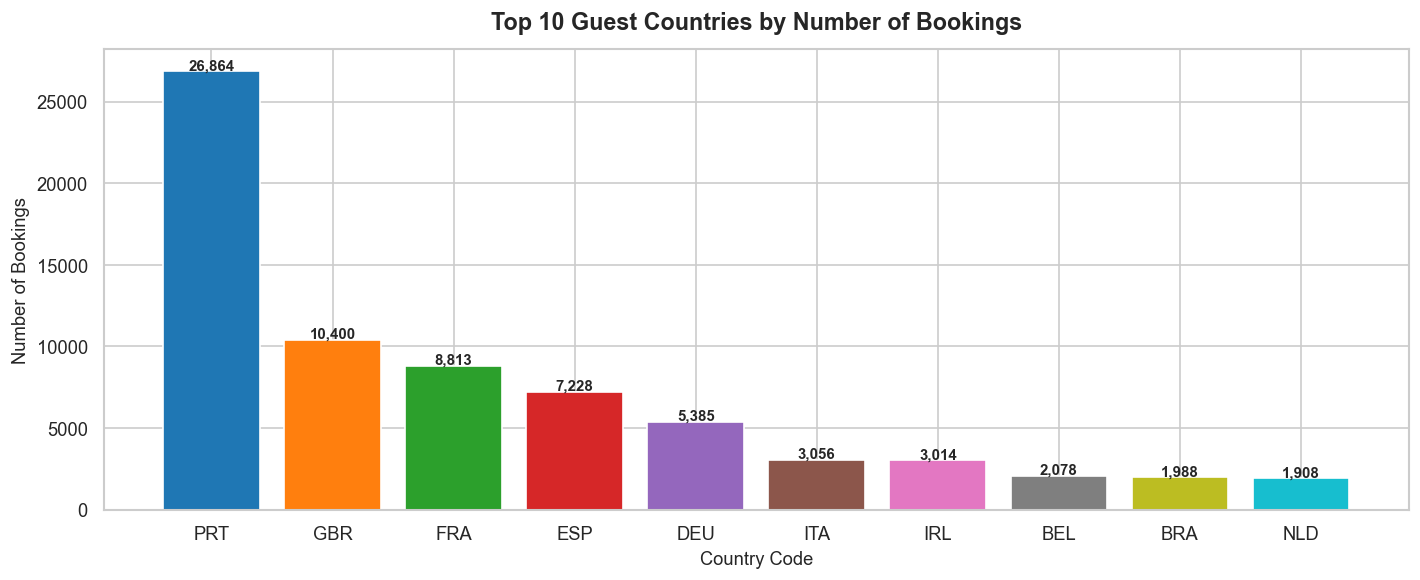

In [38]:
top10 = df['country'].value_counts().head(10)

plt.figure(figsize=(12, 5))
bars = plt.bar(top10.index, top10.values, color=sns.color_palette('tab10', 10), edgecolor='white')
plt.title('Top 10 Guest Countries by Number of Bookings', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Country Code', fontsize=11)
plt.ylabel('Number of Bookings', fontsize=11)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{bar.get_height():,}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_countries.png', bbox_inches='tight', dpi=120)
plt.show()


> **Insights**
> - Portugal's dominance as the top source market (~30%) reflects local market strength but also concentration risk. UK, France, and Germany represent the highest-value diversification targets given their booking volumes. Geographic diversification could reduce dependency on local booking patterns and seasonal demand fluctuations.


### 4.10 Season-wise Revenue and Cancellation Rate

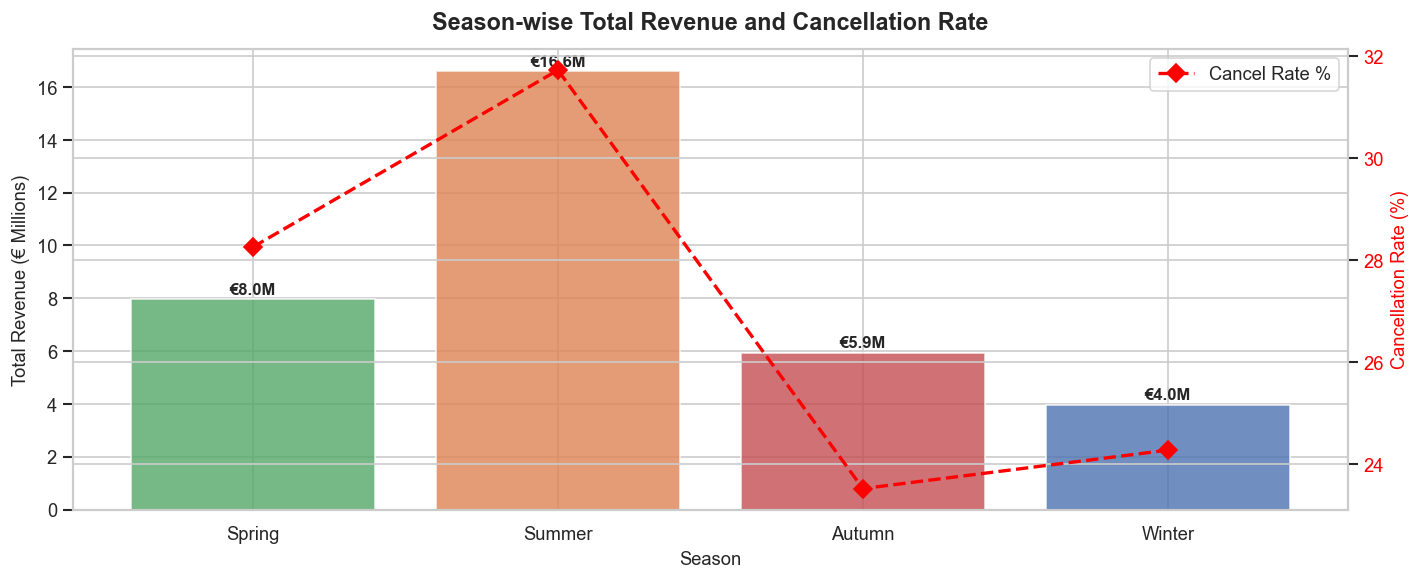

In [39]:
season_order = ['Spring','Summer','Autumn','Winter']
season_stats = df.groupby('season').agg(
    total_revenue=('total_revenue','sum'),
    cancel_rate=('is_canceled','mean'),
    avg_adr=('adr','mean')
).reindex(season_order)
season_stats['cancel_rate'] *= 100

fig, ax1 = plt.subplots(figsize=(12, 5))

palette = ['#55A868','#DD8452','#C44E52','#4C72B0']
bars = ax1.bar(season_stats.index, season_stats['total_revenue']/1e6,
               color=palette, alpha=0.8, edgecolor='white')
ax1.set_title('Season-wise Total Revenue and Cancellation Rate', fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Season', fontsize=11)
ax1.set_ylabel('Total Revenue (€ Millions)', fontsize=11)
for bar in bars:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'€{bar.get_height():.1f}M', ha='center', fontsize=10, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(season_stats.index, season_stats['cancel_rate'], 'D--', color='red',
         linewidth=2, markersize=8, label='Cancel Rate %')
ax2.set_ylabel('Cancellation Rate (%)', fontsize=11, color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('plot_season.png', bbox_inches='tight', dpi=120)
plt.show()


> **Insights**
> - Summer generates the highest total revenue but also maintains high cancellation rates — net revenue is lower than gross suggests. Winter has both lowest revenue and lowest cancellation rates, indicating committed leisure travellers. Autumn shows the best revenue-to-cancellation balance, making it an underutilised yield management opportunity.


### 4.11 Meal Plan Distribution by Hotel Type

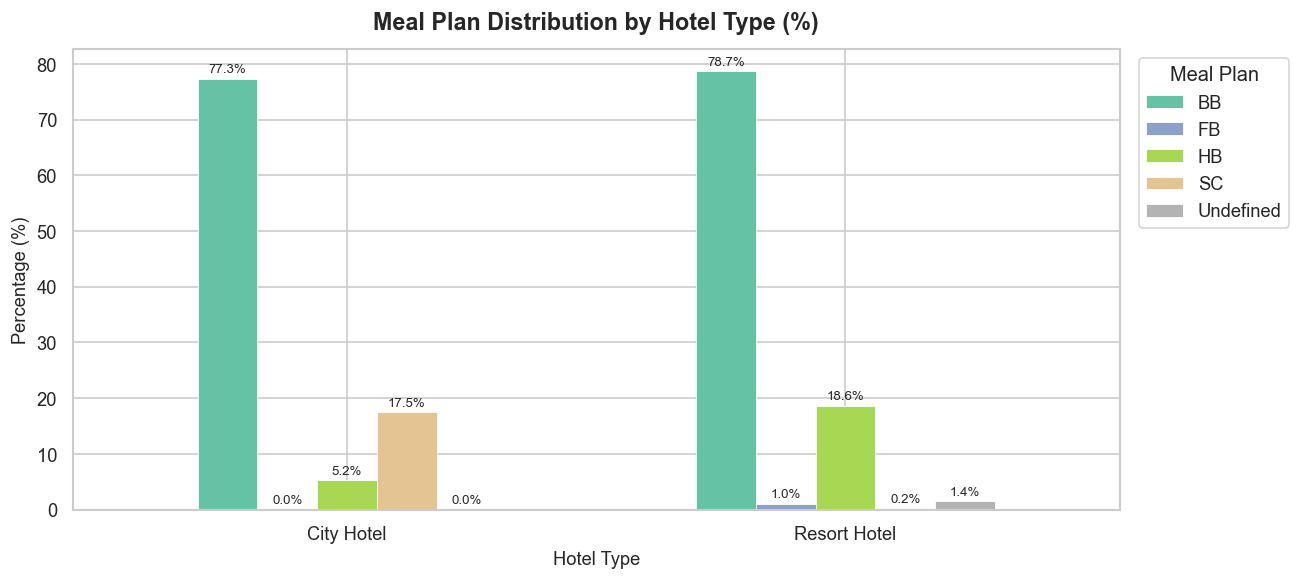

In [40]:
meal_hotel = df.groupby(['hotel','meal']).size().unstack(fill_value=0)
meal_hotel = meal_hotel.div(meal_hotel.sum(axis=1), axis=0) * 100

ax = meal_hotel.plot(kind='bar', figsize=(11,5), colormap='Set2',
                     edgecolor='white', linewidth=0.5, width=0.6)
plt.title('Meal Plan Distribution by Hotel Type (%)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Hotel Type', fontsize=11)
plt.ylabel('Percentage (%)', fontsize=11)
plt.xticks(rotation=0)
plt.legend(title='Meal Plan', bbox_to_anchor=(1.01,1), loc='upper left')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8, padding=2)
plt.tight_layout()
plt.savefig('plot_meal.png', bbox_inches='tight', dpi=120)
plt.show()


> **Insights**
> - BB (Bed & Breakfast) dominates both hotel types at ~75–80%, reflecting the standard European hospitality expectation. Resort Hotels have a slightly higher share of HB (Half Board) and FB (Full Board), consistent with their longer-stay leisure profile. The SC (Self-Catering) option appears minimally in both types.


### 4.12 Scatter Plot — Lead Time vs ADR (coloured by cancellation)

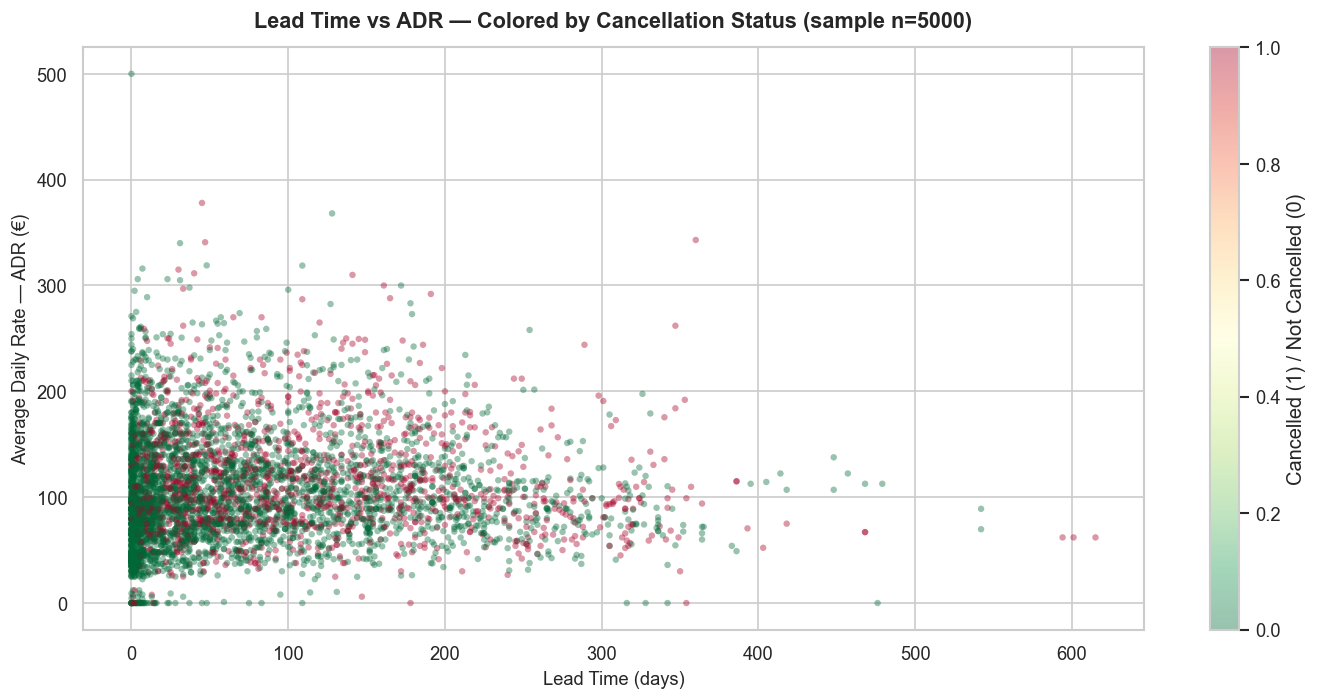

In [41]:
sample = df.sample(5000, random_state=42)

plt.figure(figsize=(12, 6))
scatter = plt.scatter(sample['lead_time'], sample['adr'].clip(0,500),
                      c=sample['is_canceled'], cmap='RdYlGn_r',
                      alpha=0.4, s=15, edgecolors='none')
plt.colorbar(scatter, label='Cancelled (1) / Not Cancelled (0)')
plt.title('Lead Time vs ADR — Colored by Cancellation Status (sample n=5000)',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Lead Time (days)', fontsize=11)
plt.ylabel('Average Daily Rate — ADR (€)', fontsize=11)
plt.tight_layout()
plt.savefig('plot_scatter_lead_adr.png', bbox_inches='tight', dpi=120)
plt.show()


> **Insights**
> - Red-coded (cancelled) bookings cluster visibly at higher lead times, confirming the lead time–cancellation relationship. At lower ADRs (<€100), cancellations are more diffuse across all lead times — budget bookings cancel regardless of timing. Higher-ADR bookings at shorter lead times tend to be more reliable, possibly reflecting corporate or direct booking behaviour.


---
#  Insights and Report

##  Key Findings

## 1. Hotel Type Insights ##

City Hotels account for the majority of bookings compared to Resort Hotels, though Resort Hotels command a higher ADR on average, indicating a premium pricing tier. This likely reflects longer leisure stays and a less price-sensitive guest base compared to City Hotel's more transactional clientele. As a result, Resort Hotels generate more revenue per booking despite lower volume.

---

## 2. Seasonal Patterns ##

Summer (June–August) records the highest booking volumes and ADRs — the clear peak season for both hotel types — while January and February mark a predictable off-season trough. ADR follows a clean bell curve that peaks in summer, confirming current dynamic pricing is broadly working. The shoulder months (spring and autumn) may be underpriced relative to their actual demand.

---

## 3. Cancellation Analysis ##

The overall cancellation rate is ~27%, a major revenue risk, with No Deposit bookings cancelling at ~99% — likely speculative OTA reservations never intended to materialise. Online TA and Groups segments cancel most frequently, and longer lead times strongly correlate with higher cancellations. The highest-risk profile is a long-lead-time, no-deposit, OTA-sourced booking.

---

## 4. Revenue Insights ##

Online TA generates the most bookings but also the most cancellations, weakening its net revenue contribution once cancellations are stripped out. Direct bookings show lower cancellation rates and stable ADRs, making them the most reliable revenue source per booking. Total revenue peaks in Summer and troughs in Winter, mirroring the seasonal booking pattern.

---

## 5. Guest Behaviour ##

Portugal (PRT) dominates as the top source country, followed by the UK, France, Spain, and Germany — a notable concentration risk. Repeat guests cancel far less often than new guests (~8% vs ~28%), confirming clear loyalty value, and guests with more special requests are also less likely to cancel. BB (Bed & Breakfast) remains the dominant meal plan, especially in City Hotels.

---
## 6. Waiting List Patterns ##

Days in waiting list shows near-zero correlation with cancellation, suggesting guests who wait for a room are genuinely committed to the booking. This makes waitlisted reservations a relatively low-risk segment for inventory planning. Properties don't need to over-buffer capacity against the assumption that these guests will drop off.


---
# Recommendations

| # | Insight | Recommendation |
|---|---------|----------------|
| 1 | High OTA cancellation rate | Incentivise direct bookings with loyalty discounts, simplified booking flows, and rate-matching against OTA prices to pull volume away from the least reliable channel |
| 2 | No-deposit bookings cancel at ~99% | Re-evaluate the No-Deposit policy for long lead-time OTA bookings, potentially requiring a partial deposit once lead time exceeds a defined threshold (e.g. 60–90 days) |
| 3 | City Hotel has a high cancellation rate | Implement overbooking strategies and waitlist management calibrated specifically to City Hotel's cancellation curve rather than applying a blanket policy across both property types |
| 4 | Summer is peak season | Dynamic pricing should maximise ADR in June–August, and the same demand-responsive logic should be tested in the shoulder months to capture any underpriced demand |
| 5 | Repeat guests cancel rarely | Invest in CRM & loyalty programs to grow repeat guest share, since this segment is both the most reliable and the most cost-effective to retain relative to new guest acquisition |
| 6 | Long lead-time bookings cancel more | Send personalised pre-arrival communication for 90+ day bookings — a simple reminder or confirmation touchpoint may reduce silent drop-off |
| 7 | PRT is the top source country | Target marketing budgets toward UK, France & Germany for diversification, reducing reliance on a single dominant market |


---
# Conclusion

The analysis reveals that hotel revenue optimisation is less about attracting more bookings and more about retaining the right bookings. With a 27% cancellation rate, the single biggest lever for revenue improvement is reducing cancellations — especially through better deposit policies, direct booking incentives, and proactive guest communication for long-lead bookings. The data points to a fairly specific failure mode rather than a diffuse one: no-deposit, long-lead, OTA-sourced bookings are disproportionately responsible for the cancellation problem, which means the fix can be targeted rather than organization-wide.

Summer seasonality is a double-edged sword: it offers the highest revenue opportunity but must be protected with intelligent overbooking and dynamic pricing strategies, since peak-season cancellations carry a higher opportunity cost than off-season ones simply because the foregone revenue per room-night is larger. Investing in guest loyalty is the clearest long-term recommendation — repeat guests not only cancel less but also generate reliable, predictable revenue, and because this segment is currently small relative to new guests, even modest growth in repeat-guest share could meaningfully shift the overall cancellation rate over time.

